In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from scipy.optimize import minimize

import seaborn as sns
from tqdm import tqdm

import pyarrow as pa
import pyarrow.parquet as pq
import copy
import glob
import os
import warnings
warnings.simplefilter("ignore")

sns.set_style("darkgrid")

### Read data and convert to the form

In [2]:
def read_pq(date: str,full = False, instrument: str | None = None,  exc: str | None = None):
    # read all the parquet file downloaded
    root = f"C:/GIT/market_game/market_data/NIFTY_FUT/2026-{date}"

    all_files = glob.glob(
        "**/*.parquet",
        root_dir=root,
        recursive=True
    )

    df = pd.DataFrame()
    
    i = 1
    
    #club all the files into a single one
    for file_name in all_files:
        try:
            if instrument is None:
                _df = pd.read_parquet(os.path.join(root, file_name))
            else:
                _df = pd.read_parquet(os.path.join(root, file_name))
                _df = _df[_df['security_id'] == instrument]
        except:
            continue
        
        df = pd.concat([df, _df], axis= 0)
    
    '''
    compute the mid price and 
    normalize the price so that we are concerned of only the distance from centre
    '''
    if full:
        
        __ask = df[df["side"] == "Ask"].groupby("snap_idx")["price"].min()
        __bid = df[df["side"] == "Bid"].groupby("snap_idx")["price"].max()
        __mid = 0.5*(__ask + __bid)

        df = df.reset_index(drop = True)
        df["price_norm"] = df["price"] - df["snap_idx"].map(__mid)
        
        # considering only NIFTY future with lot = 65
        if exc == 'fno':
            df["qty_norm"] = df["qty"] / 65 
        else:
            df["qty_norm"] = df["qty"]  
        
        return df, __mid
    else:
        return df, None
        

In [3]:
full= True
# df_market, mid_price = read_pq('02-27', full, '51714', 'fno')
df_market, mid_price = read_pq('03-05', full, '2885')#, 'fno')


# 3 Convert DataFrame → Orderbook Snapshots

In [5]:
LEVELS = 20
TRAIN_SNAPSHOTS = 500
HORIZON = 50
#per stock cost ~ .5 INR
TICK = 0.5
ExitTime = 25

In [6]:
def dataframe_to_snapshots(df):
    book=[]
    for snap,grp in df.groupby("snap_idx"):
        bid=grp[grp.side=="Bid"].sort_values("price",ascending=False)
        ask=grp[grp.side=="Ask"].sort_values("price")
        book.append({
            "bid_prices":bid.price.values[:LEVELS],
            "ask_prices":ask.price.values[:LEVELS],
            "bid_vol":bid.qty.values[:LEVELS],
            "ask_vol":ask.qty.values[:LEVELS]
        })
    return book


In [7]:
book = dataframe_to_snapshots(df_market)

## Kelly Yudovina Implementation

In [178]:
class BinnedLOB_CTMC_Data:
    def __init__(self, book, times=None, N=50, tick=0.01, seed=None):
        self.book = book
        self.N = N
        self.tick = tick
        self.rng = np.random.default_rng(seed)
        self.times = times if times is not None else np.arange(len(book))
        # smoothed mid
        self.mid_series = self._compute_smoothed_mid()
        # queues
        self.Qb = np.zeros(N, dtype=int)
        self.Qa = np.zeros(N, dtype=int)
        self.time = 0.0
        # history
        self.time_hist = []
        self.beta_hist = []
        self.alpha_hist = []
        # arrival distributions
        self.pb, self.pa = self._estimate_arrival_probs()
        # empirical time increments
        self.dt_series = self._estimate_inter_event_times()
        # initialize queue
        self._initialize_from_snapshot(0)

    def _compute_smoothed_mid(self):
        mids = []
        for snap in self.book:
            mid = (snap["bid_prices"][0] + snap["ask_prices"][0]) / 2
            mids.append(mid)
        mids = pd.Series(mids)
        return mids.rolling(10, min_periods=1).mean().values

    def _initialize_from_snapshot(self, t):
        snap = self.book[t]
        mid = self.mid_series[t]
        mid = (snap["bid_prices"].max() + snap["ask_prices"].min()) / 2
        for p, v in zip(snap["bid_prices"], snap["bid_vol"]):
            d = int((mid - p) / self.tick)
            if 0 <= d < self.N:
                self.Qb[d] += int(v)

        for p, v in zip(snap["ask_prices"], snap["ask_vol"]):
            d = int((p - mid) / self.tick)
            if 0 <= d < self.N:
                self.Qa[d] += int(v)

    def _estimate_arrival_probs(self):
        bid_counts = np.zeros(self.N)
        ask_counts = np.zeros(self.N)
        for t, snap in enumerate(self.book):
            # mid = self.mid_series[t]
            mid = (snap["bid_prices"].max() + snap["ask_prices"].min()) / 2
            for p in snap["bid_prices"]:
                d = int(round((mid - p) / self.tick))
                if 0 <= d < self.N:
                    bid_counts[d] += 1

            for p in snap["ask_prices"]:
                d = int(round((p - mid) / self.tick))
                if 0 <= d < self.N:
                    ask_counts[d] += 1

        if bid_counts.sum() == 0:
            pb = np.ones(self.N) / self.N
        else:
            pb = bid_counts / bid_counts.sum()

        if ask_counts.sum() == 0:
            pa = np.ones(self.N) / self.N
        else:
            pa = ask_counts / ask_counts.sum()
        pb = pb / pb.sum()
        pa = pa / pa.sum()

        return pb, pa

    def _estimate_inter_event_times(self):
        dt = np.diff(self.times)
        if len(dt) == 0:
            return np.ones(len(self.book))
        return dt

    def _highest_bid_bin(self):
        idx = np.where(self.Qb > 0)[0]
        return idx[-1] if len(idx) > 0 else -1

    def _lowest_ask_bin(self):
        idx = np.where(self.Qa > 0)[0]
        return idx[0] if len(idx) > 0 else -1

    def _process_bid(self, k):
        asks = np.where(self.Qa[:k+1] > 0)[0]
        if len(asks) > 0:
            i = asks.min()
            self.Qa[i] = max(self.Qa[i] - 1, 0)
        else:
            self.Qb[k] += 1

    def _process_ask(self, k):
        bids = np.where(self.Qb[:k+1] > 0)[0]
        if len(bids) > 0:
            i = bids.max()
            self.Qb[i] = max(self.Qb[i] - 1, 0)
        else:
            self.Qa[k] += 1

    def _record(self):
        hb = self._highest_bid_bin()
        la = self._lowest_ask_bin()
        self.time_hist.append(self.time)
        self.beta_hist.append(hb)
        self.alpha_hist.append(la)

    def step(self, t):
        if t >= len(self.dt_series):
            return
        dt = self.dt_series[t]
        self.time += dt
        is_bid = self.rng.random() < 0.5
        
        if is_bid:
            k = self.rng.choice(self.N, p=self.pb)
            self._process_bid(k)

        else:
            k = self.rng.choice(self.N, p=self.pa)
            self._process_ask(k)
        self._record()

    def run(self):
        for t in range(len(self.dt_series)):
            self.step(t)


    def update_from_segment(self, book_segment, times_segment=None):
        self.book = book_segment
        if times_segment is not None:
            self.times = times_segment
        else:
            self.times = np.arange(len(book_segment))
        self.mid_series = self._compute_smoothed_mid()
        self.pb, self.pa = self._estimate_arrival_probs()
        self.dt_series = self._estimate_inter_event_times()

In [179]:
window = 25
lob = BinnedLOB_CTMC_Data(book[:window])
lob.run()
for start in range(window, len(book), window):
    segment = book[start:start+window]
    lob.update_from_segment(segment)
    lob.run()

In [180]:
N = lob.N
bin_centers = (np.arange(N) + 0.5) / N

beta = np.array([b if b is not None else -1 for b in lob.beta_hist])
alpha = np.array([a if a is not None else -1 for a in lob.alpha_hist])

beta_price = np.where(beta >= 0, bin_centers[beta], np.nan)
alpha_price = np.where(alpha >= 0, bin_centers[alpha], np.nan)

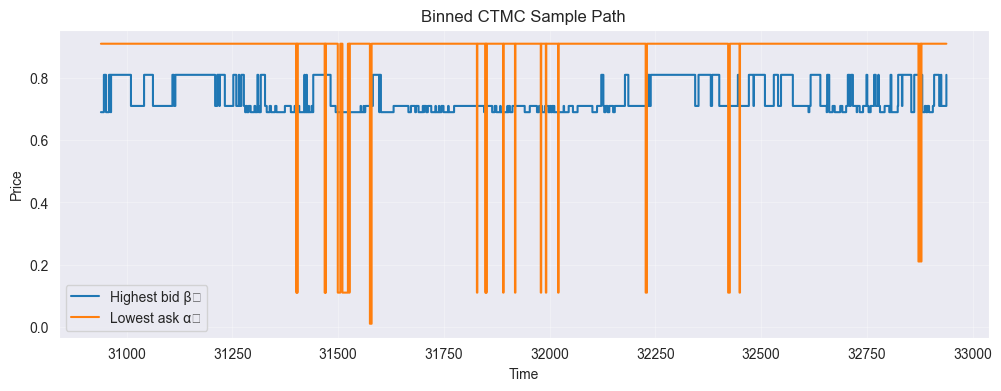

In [181]:
t = np.array(lob.time_hist)

idx = t > t[-1] - 2000

plt.figure(figsize=(12,4))
plt.step(t[idx], beta_price[idx], where="post", label="Highest bid βₜ")
plt.step(t[idx], alpha_price[idx], where="post", label="Lowest ask αₜ")
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Binned CTMC Sample Path")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

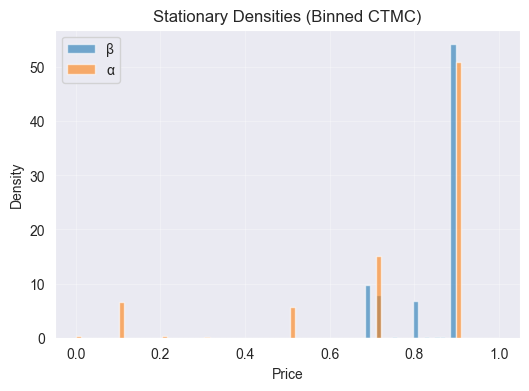

In [182]:
# burn = 50_000
burn = 0

beta_clean = beta_price[burn:]
alpha_clean = alpha_price[burn:]

beta_clean = beta_clean[~np.isnan(beta_clean)]
alpha_clean = alpha_clean[~np.isnan(alpha_clean)]

bins = np.linspace(0,1,80)

plt.figure(figsize=(6,4))
plt.hist(beta_clean, bins=bins, density=True, alpha=0.6, label="β")
plt.hist(alpha_clean, bins=bins, density=True, alpha=0.6, label="α")
plt.xlabel("Price")
plt.ylabel("Density")
plt.title("Stationary Densities (Binned CTMC)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### <u>ISSUES</u>
Not sufficient data points <br>
Theoritical distribution assumption is in-valid for real data <br>
emperical distribution is unreliable<br>
High sensitivity to tick size <br>
Data not smooth to be fit into a distribution<br><br>
<u><b> Conclusion </u></b> <br>
Did not pursue this approach


## Model

In [17]:
## Get mid price and micro features from the order book snapshot
def get_mid_price(snap):
    return (snap["bid_prices"][0] + snap["ask_prices"][0]) / 2

def micro_features(snap):
    spread=snap["ask_prices"][0]-snap["bid_prices"][0]
    bid_depth=np.sum(snap["bid_vol"][:5])
    ask_depth=np.sum(snap["ask_vol"][:5])
    imbalance=(bid_depth-ask_depth)/(bid_depth+ask_depth+1e-8)
    return spread,imbalance,bid_depth,ask_depth

In [18]:
get_mid_price(book[0])
micro_features(book[0])

(np.float64(-0.10000000000013642),
 np.float64(0.13797351401272256),
 np.int64(3695),
 np.int64(2799))

In [19]:
# USing K Means to identify regimes based on micro features
def regime_features(book):
    feats = []
    for snap in book:
        spread,imb,bid,ask = micro_features(snap)
        feats.append([spread,imb,bid,ask])
    return np.array(feats)


def train_regime_model(book):
    X = regime_features(book)
    model = KMeans(n_clusters=3, random_state=0)
    regimes = model.fit_predict(X)
    return model, regimes

In [20]:
# estimate queue fill probability based on the current queue and order size
def estimate_queue_fill_probability(snap, order_size=1):
    queue_ahead = snap["bid_vol"][0]
    if queue_ahead == 0:
        return 1
    return min(order_size / queue_ahead, 1)

In [21]:
DIST_BUCKETS = [0,1,2,4,8,20]
VOL_BUCKETS = [1,10,25,50,100]

def distance_from_mid(price, mid, tick=TICK):
    return abs(price-mid)/tick

def get_bucket(value, buckets):
    for i in range(len(buckets)-1):
        if buckets[i] <= value < buckets[i+1]:
            return i
    return len(buckets)-2

In [22]:
## Regime specific 
# 5 is an arbitary number, we can tune it based on the exit time we want to consider for the fill probability

def build_regime_surfaces(book, regimes, horizon=HORIZON, depth = LEVELS, tau = ExitTime):
    bid_surfaces = {}
    ask_surfaces = {}
    
    for r in np.unique(regimes):
        counts_bid = np.zeros((len(DIST_BUCKETS)-1,len(VOL_BUCKETS)-1))
        counts_ask = np.zeros((len(DIST_BUCKETS)-1,len(VOL_BUCKETS)-1))
        
        fills_bid = np.zeros_like(counts_bid)
        fills_ask = np.zeros_like(counts_ask)
        
        idx = np.where(regimes==r)[0]
        
        for t in idx:
            if t+horizon >= len(book):
                continue
                
            snap = book[t]
            future = book[t+horizon]
            mid = get_mid_price(snap)
            
            for level in range(depth):
                bid_price = snap['bid_prices'][level]
                bid_vol = snap['bid_vol'][level]
                
                bid_dist = distance_from_mid(bid_price,mid)
                d_bin_bid = get_bucket(bid_dist,DIST_BUCKETS)
                v_bin_bid = get_bucket(bid_vol,VOL_BUCKETS)
                
                ask_price = snap['ask_prices'][level]
                ask_vol = snap['ask_vol'][level]
                
                ask_dist = distance_from_mid(ask_price,mid)
                d_bin_ask = get_bucket(ask_dist,DIST_BUCKETS)
                v_bin_ask = get_bucket(ask_vol,VOL_BUCKETS)
                
                counts_bid[d_bin_bid,v_bin_bid]+=1
                counts_ask[d_bin_ask,v_bin_ask]+=1
                
                # if future['ask_prices'][:tau].any() <= bid_price:
                if sum(future['ask_prices'][:tau] <= bid_price) > 5:
                    fills_bid[d_bin_bid,v_bin_bid]+=1
                
                # if future['bid_prices'][:tau].any() >= ask_price:
                if sum(future['bid_prices'][:tau] >= ask_price) > 5:
                    fills_ask[d_bin_ask,v_bin_ask]+=1
        
        bid_surfaces[r] = fills_bid/(counts_bid+1e-8)
        ask_surfaces[r] = fills_ask/(counts_ask+1e-8)
    
    return bid_surfaces, ask_surfaces

In [23]:
model, regimes = train_regime_model(book)
bid_surfaces, ask_surfaces = build_regime_surfaces(book, regimes, horizon=HORIZON)

In [24]:
regimes

array([2, 2, 2, ..., 2, 2, 2], shape=(34311,), dtype=int32)

In [25]:
bid_surfaces

{np.int32(0): array([[0.109375  , 0.14012739, 0.02762431, 0.33470011],
        [0.5       , 0.        , 0.81818182, 0.26755284],
        [0.65957447, 0.62068965, 0.8       , 0.25266086],
        [0.88461538, 0.83870968, 0.57142857, 0.40662983],
        [0.        , 0.        , 0.        , 0.5       ]]),
 np.int32(1): array([[0.42322097, 0.32881356, 0.49197861, 0.46525159],
        [0.84615385, 0.9       , 0.75      , 0.39129283],
        [0.85714286, 0.70967742, 0.68181818, 0.36333144],
        [0.81818182, 0.63157895, 0.62162162, 0.48643627],
        [0.        , 0.        , 0.        , 0.        ]]),
 np.int32(2): array([[0.26932084, 0.25048638, 0.2220339 , 0.36988966],
        [0.58375635, 0.56701031, 0.6       , 0.3079903 ],
        [0.70607029, 0.70175439, 0.68222222, 0.27234872],
        [0.72151899, 0.71455224, 0.62209302, 0.54664734],
        [0.87671233, 1.        , 0.9375    , 0.89990983]])}

In [74]:
ask_surfaces

{np.int32(0): array([[0.16372796, 0.22      , 0.18685832, 0.35650675],
        [0.57894737, 0.17647059, 0.2173913 , 0.28407852],
        [0.70588235, 0.54347826, 0.69662921, 0.25169768],
        [0.64516129, 0.68292683, 0.69090909, 0.34841307],
        [0.        , 0.        , 0.        , 0.45454545]]),
 np.int32(1): array([[0.22222222, 0.14545455, 0.34482759, 0.34222007],
        [0.63636364, 0.77777778, 0.125     , 0.2768905 ],
        [0.8       , 0.60714286, 0.45454545, 0.23846035],
        [0.99999999, 0.66666667, 0.5       , 0.42010625],
        [0.        , 0.        , 0.        , 0.        ]]),
 np.int32(2): array([[0.21311475, 0.25323349, 0.32836645, 0.39128943],
        [0.61643836, 0.5154185 , 0.58549223, 0.31942098],
        [0.7124183 , 0.67064439, 0.74401473, 0.28906287],
        [0.7027027 , 0.73611111, 0.70376176, 0.51802714],
        [0.66666667, 0.84444444, 0.825     , 0.92653811]])}

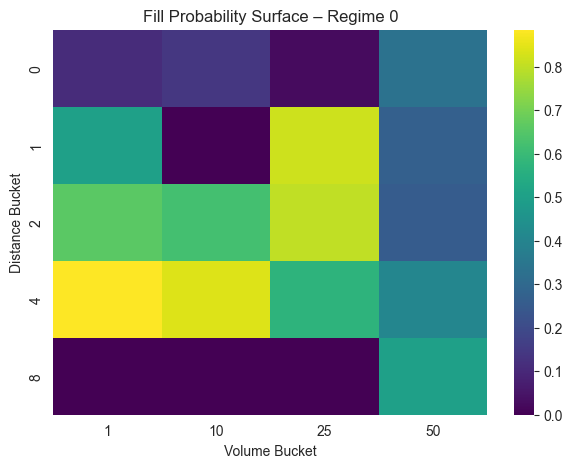

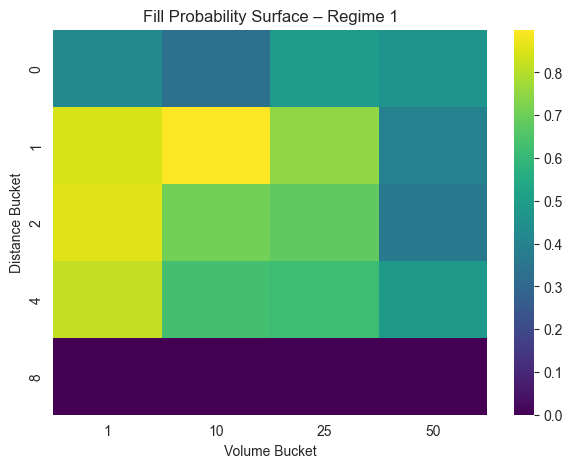

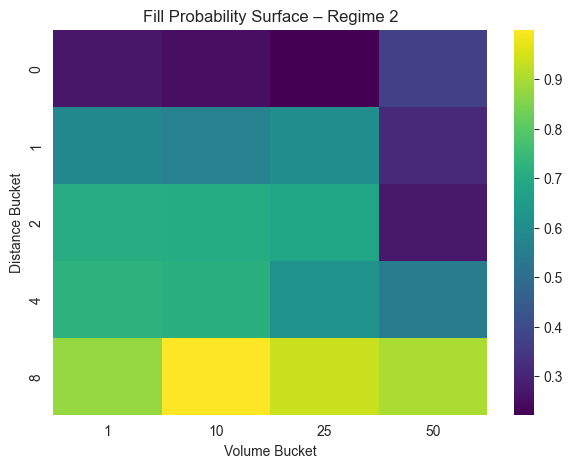

In [27]:
def plot_regime_surface(surface, regime):

    plt.figure(figsize=(7,5))
    sns.heatmap(
        surface,
        cmap="viridis",
        xticklabels=VOL_BUCKETS[:-1],
        yticklabels=DIST_BUCKETS[:-1]
    )
    plt.title(f"Fill Probability Surface – Regime {regime}")
    plt.xlabel("Volume Bucket")
    plt.ylabel("Distance Bucket")

    plt.show()

for r in bid_surfaces:
    plot_regime_surface(bid_surfaces[r], r)

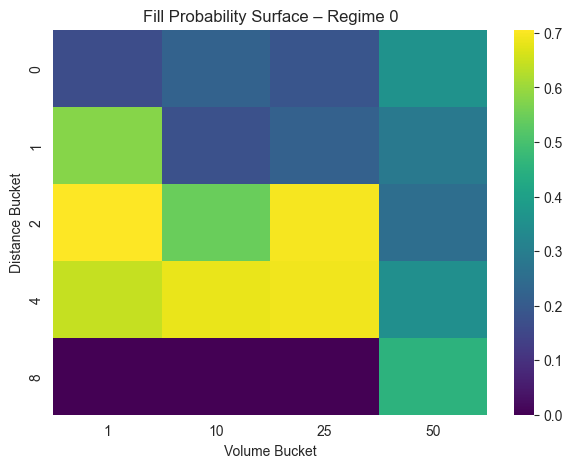

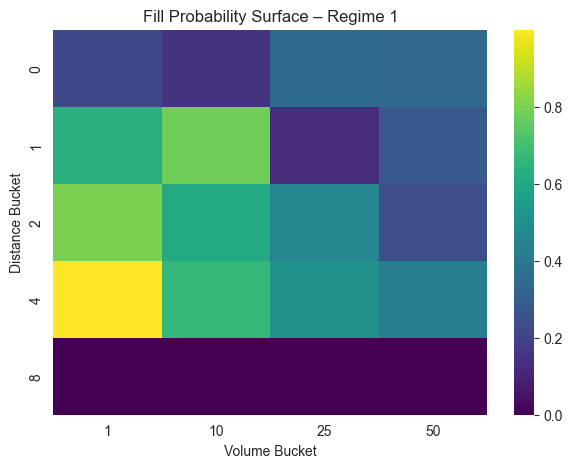

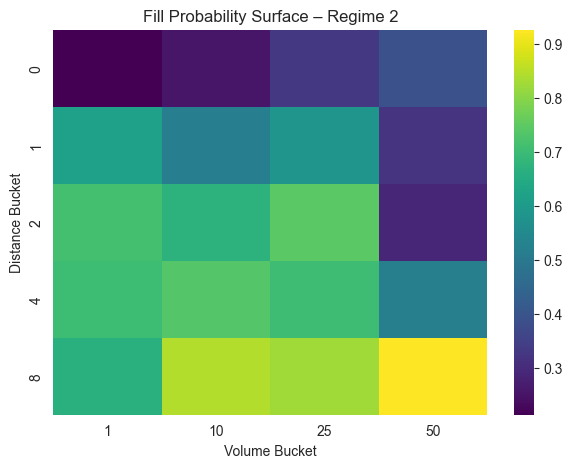

In [28]:
for r in ask_surfaces:
    plot_regime_surface(ask_surfaces[r], r)

In [81]:
#based on surface forecast
def query_fill_probability(price, volume, mid, surface, regime):

    dist = distance_from_mid(price, mid)

    d_bin = get_bucket(dist, DIST_BUCKETS)
    v_bin = get_bucket(volume, VOL_BUCKETS)
    return surface[regime][d_bin, v_bin]

bid_prob = []
ask_prob = []

bid_prob2 = []
bid_prob5 = []
bid_prob10 = []
ask_prob2 = []
ask_prob5 = []
ask_prob10 = []

# Using the Surfaces calibrated in the above step to query fill probabilities for new snapshots
# Make market only in regime 2.
for t in tqdm(range(500, len(book))):

    for i in [0,2,5,10]:
        snap = book[t]
        mid = get_mid_price(snap)
        bid_price = snap["bid_prices"][i]
        bid_vol   = snap["bid_vol"][i]
        
        ask_price = snap["ask_prices"][i]
        ask_vol   = snap["ask_vol"][i]
        
        regime = model.predict([regime_features([snap])[0]])[0]
        
        # if regime ==0 or regime == 2:
        if regime > 2:
        
            if i == 0:
                bid_prob.append(0.0)
                ask_prob.append(0.0)
            elif i == 2:
                bid_prob2.append(0.0)
                ask_prob2.append(0.0)   
            elif i == 5:
                bid_prob5.append(0.0)
                ask_prob5.append(0.0)
            elif i == 10:
                bid_prob10.append(0.0)
                ask_prob10.append(0.0)
            # bid_prob.append(0.0)
            # ask_prob.append(np.float(0))
        else:
            if i == 0:
                bid_prob.append(query_fill_probability(bid_price, bid_vol, mid, bid_surfaces, regime))
                ask_prob.append(query_fill_probability(ask_price, ask_vol, mid, ask_surfaces, regime))
            elif i == 2:
                bid_prob2.append(query_fill_probability(bid_price, bid_vol, mid, bid_surfaces, regime))
                ask_prob2.append(query_fill_probability(ask_price, ask_vol, mid, ask_surfaces, regime))
            elif i == 5:
                bid_prob5.append(query_fill_probability(bid_price, bid_vol, mid, bid_surfaces, regime))
                ask_prob5.append(query_fill_probability(ask_price, ask_vol, mid, ask_surfaces, regime))
            elif i == 10:
                bid_prob10.append(query_fill_probability(bid_price, bid_vol, mid, bid_surfaces, regime))
                ask_prob10.append(query_fill_probability(ask_price, ask_vol, mid, ask_surfaces, regime))
            # bid_prob.append(query_fill_probability(bid_price, bid_vol, mid, bid_surfaces, regime))
            # ask_prob.append(query_fill_probability(ask_price, ask_vol, mid, ask_surfaces, regime))

100%|██████████| 33811/33811 [00:11<00:00, 3047.26it/s]


<Axes: title={'center': 'Bid Fill Probability Over Time'}>

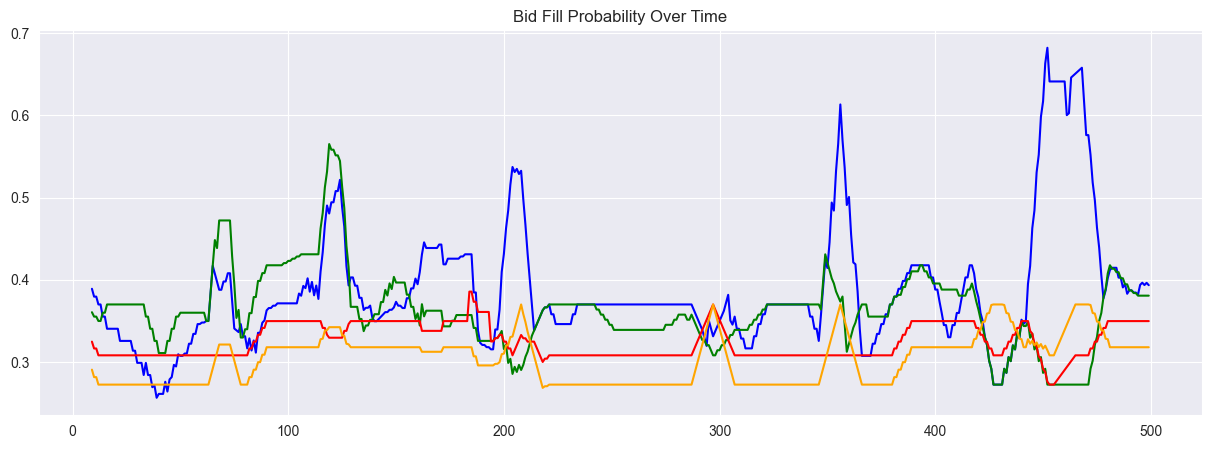

In [83]:
a= 6000 
b = 6500
pd.Series(bid_prob[a:b]).rolling(window=10).mean().plot(figsize=(15,5), color = 'blue')   
pd.Series(bid_prob2[a:b]).rolling(window=10).mean().plot(figsize=(15,5), color = 'green')
pd.Series(bid_prob5[a:b]).rolling(window=10).mean().plot(figsize=(15,5), color = 'red')
pd.Series(bid_prob10[a:b]).rolling(window=10).mean().plot(figsize=(15,5), color = 'orange', title="Bid Fill Probability Over Time")


<Axes: title={'center': 'Ask Fill Probability Over Time'}>

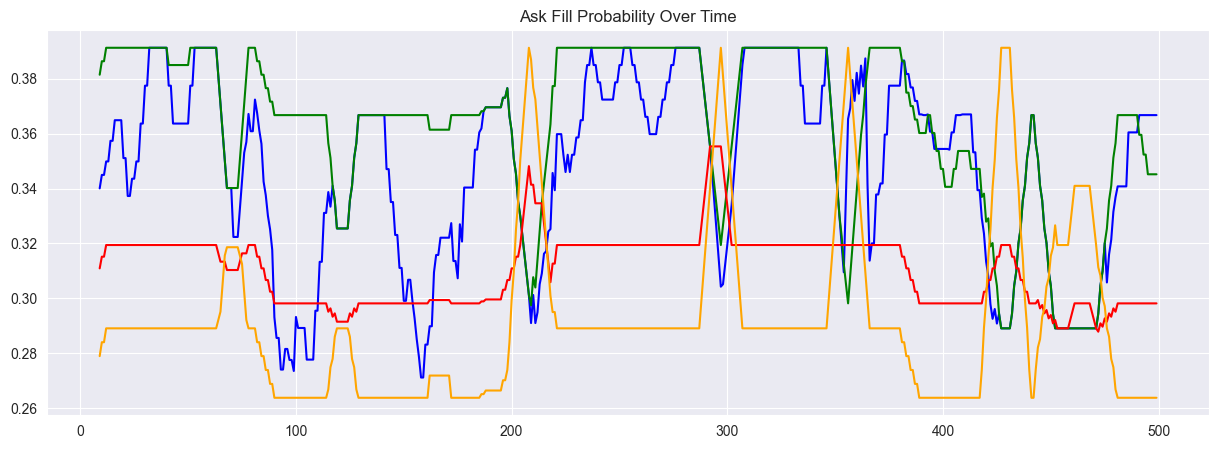

In [84]:
pd.Series(ask_prob[a:b]).rolling(window=10).mean().plot(figsize=(15,5), color = 'blue')   
pd.Series(ask_prob2[a:b]).rolling(window=10).mean().plot(figsize=(15,5), color = 'green')
pd.Series(ask_prob5[a:b]).rolling(window=10).mean().plot(figsize=(15,5), color = 'red')
pd.Series(ask_prob10[a:b]).rolling(window=10).mean().plot(figsize=(15,5), color = 'orange', title="Ask Fill Probability Over Time")


In [73]:
pd.Series(regimes).value_counts()

2    26908
0     5212
1     2191
Name: count, dtype: int64

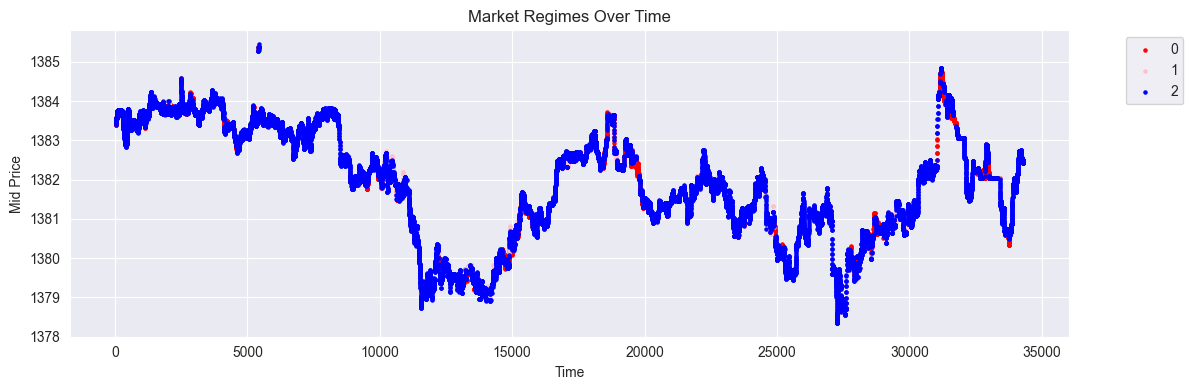

In [71]:
def plot_regimes(book, regimes, regime_names=None):
    mid_prices = []
    for snap in book:
        bid = snap["bid_prices"][0]
        ask = snap["ask_prices"][0]
        mid = (bid + ask) / 2
        mid_prices.append(mid)
    
    plt.figure(figsize=(12, 4))
    moving_avg = pd.Series(mid_prices).rolling(window=20).mean()
    
    unique_regimes = np.unique(regimes)
    
    if regime_names is None:
        regime_names = {r: f'Regime {r}' for r in unique_regimes}
    
    colors = plt.cm.plasma(np.linspace(0, 1, len(unique_regimes)))
    
    for i, regime in enumerate(unique_regimes):
        mask = np.array(regimes) == regime
        plt.scatter(np.arange(len(mid_prices))[mask],
                   moving_avg[mask],
                   c=['red','pink','blue'][i],
                   label=regime_names[regime],
                   s=5)
    
    plt.title("Market Regimes Over Time")
    plt.xlabel("Time")
    plt.ylabel("Mid Price")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage with custom names
regime_names = {
    0: '0',
    1: '1', 
    2: '2',
}
# plot_regimes(book[0:1000], regimes[0:1000], regime_names)
plot_regimes(book, regimes, regime_names)


In [48]:
book[0:1000]

[{'bid_prices': array([1383.4, 1383.3, 1383.2, 1383.2, 1383.1, 1383.1, 1383. , 1383. ,
         1382.9, 1382.9, 1382.8, 1382.8, 1382.7, 1382.7, 1382.6, 1382.6,
         1382.5, 1382.5, 1382.4, 1382.4]),
  'ask_prices': array([1383.3, 1383.4, 1383.5, 1383.6, 1383.7, 1383.7, 1383.8, 1383.8,
         1383.9, 1383.9, 1384. , 1384. , 1384.1, 1384.1, 1384.2, 1384.2,
         1384.3, 1384.3, 1384.4, 1384.4]),
  'bid_vol': array([ 157,  102,  710, 1773,  953,  195,  596, 3566,  854,  782,  917,
         1342, 1032, 1157, 1223, 1762, 3239, 3676, 4379, 1477], dtype=int32),
  'ask_vol': array([ 752, 1135,   10,  688,  214,  962, 2584,   50,  113, 1901, 2389,
          747,  917,  691, 2084, 1091, 2081,  822, 2438, 2884], dtype=int32)},
 {'bid_prices': array([1383.4, 1383.3, 1383.2, 1383.2, 1383.1, 1383.1, 1383. , 1383. ,
         1382.9, 1382.9, 1382.8, 1382.8, 1382.7, 1382.7, 1382.6, 1382.6,
         1382.5, 1382.5, 1382.4, 1382.4]),
  'ask_prices': array([1383.3, 1383.4, 1383.5, 1383.6, 1383.7,

In [ ]:
def run_visual_analysis(book,regimes,regime_probs,distances):

    # plot_lob_heatmap(book)
    # plot_imbalance(book)
    plot_regimes(book,regimes)
    for r in regime_probs:
        plot_fill_probabilities(
            distances,
            regime_probs[r]
        )
    plot_fill_surface(distances,regime_probs)

### Queue Model

In [32]:
def estimate_queue_position(snap, side="bid", level=0):
    if side=="bid":
        return snap["bid_vol"][level]
    return snap["ask_vol"][level]

def p_queue(queue_pos, traded_volume):
    if queue_pos <= 0:
        return 1
    prob = traded_volume / queue_pos
    return min(prob,1)

def estimate_traded_volume(book, t, horizon=HORIZON):
    if t+horizon >= len(book):
        return 0
    mid_now = get_mid_price(book[t])
    mid_future = get_mid_price(book[t+horizon])
    return abs(mid_future-mid_now)*100

def compute_p_queue(book, t):
    snap = book[t]
    queue_pos = estimate_queue_position(snap)
    traded_vol = estimate_traded_volume(book,t)
    return p_queue(queue_pos, traded_vol)

### Poisson Model

In [33]:
def estimate_lambda(book, window=200):
    arrivals = []
    for t in range(1,window):
        mid1 = get_mid_price(book[t-1])
        mid2 = get_mid_price(book[t])
        arrivals.append(abs(mid2-mid1))
    lam = np.mean(arrivals)*10
    return lam

# regime wise lambda estimation for the poisson process of price changes
lam = {}
for r in np.unique(regimes):
    regime_book = [book[i] for i in range(len(book)) if regimes[i] == r]
    lam[r] = estimate_lambda(regime_book, window = ExitTime)
    
def p_poisson(lam, horizon=1):
    return 1-np.exp(-lam*horizon)


In [34]:
p_poisson(lam[0]), p_poisson(lam[1]), p_poisson(lam[2])

(np.float64(0.09892489427870943),
 np.float64(0.68204115834395),
 np.float64(0.23725639025307843))

### Neural network Model

In [35]:
def build_training_data(book, horizon=5):
    X=[]
    y=[]
    for t in range(len(book)-horizon):
        snap=book[t]
        mid=get_mid_price(snap)
        spread=snap["ask_prices"][0]-snap["bid_prices"][0]
        bid_vol=np.sum(snap["bid_vol"][:5])
        ask_vol=np.sum(snap["ask_vol"][:5])
        imbalance=(bid_vol-ask_vol)/(bid_vol+ask_vol+1e-8)
        X.append([mid,spread,bid_vol,ask_vol,imbalance])
        future_mid=get_mid_price(book[t+horizon])
        y.append(1 if future_mid>mid else 0)
    return np.array(X),np.array(y)

X,y = build_training_data(book[:500])
dl_model = MLPClassifier(hidden_layer_sizes=(64,32),max_iter=200)
dl_model.fit(X,y)

def p_dl(snap):
    mid=get_mid_price(snap)
    spread=snap["ask_prices"][0]-snap["bid_prices"][0]
    bid_vol=np.sum(snap["bid_vol"][:5])
    ask_vol=np.sum(snap["ask_vol"][:5])
    imbalance=(bid_vol-ask_vol)/(bid_vol+ask_vol+1e-8)
    X=np.array([[mid,spread,bid_vol,ask_vol,imbalance]])
    return dl_model.predict_proba(X)[0,1]

In [36]:
pq = []
pp = []
pd_ = []

for t in range(500,len(book)):
    snap = book[t]
    mid = get_mid_price(snap)
    price = snap["bid_prices"][0]
    volume = snap["bid_vol"][0]
    # models
    # ps = p_surface(price,volume,mid)
    pq.append(compute_p_queue(book,t))
    # pp.append(p_poisson(lam))
    pd_.append(p_dl(snap))



<Axes: title={'center': 'Queue Fill Probability Over Time'}>

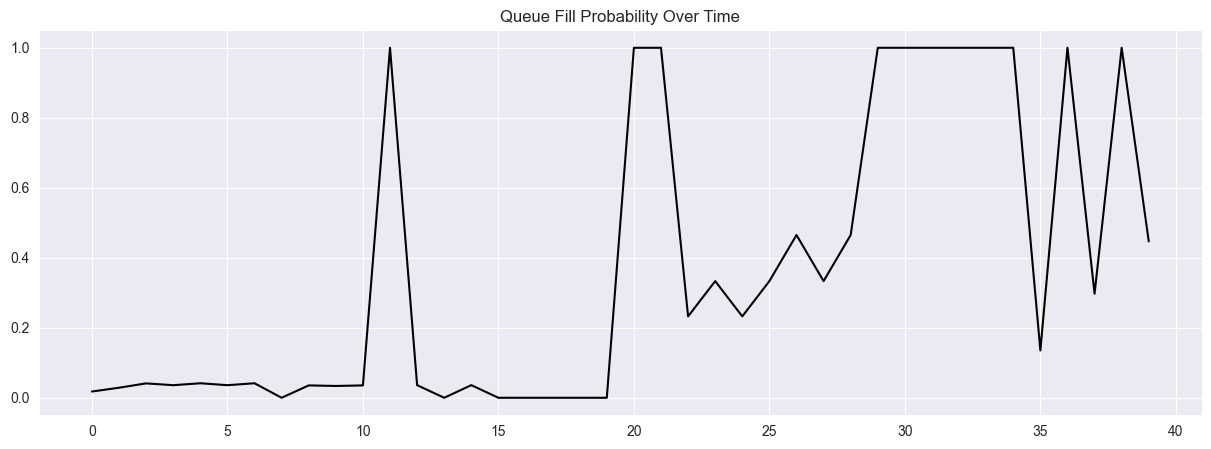

In [37]:
pd.Series(pq[a:b]).plot(figsize=(15,5), color = 'black', title="Queue Fill Probability Over Time")

<Axes: title={'center': 'Queue Fill Probability Over Time'}>

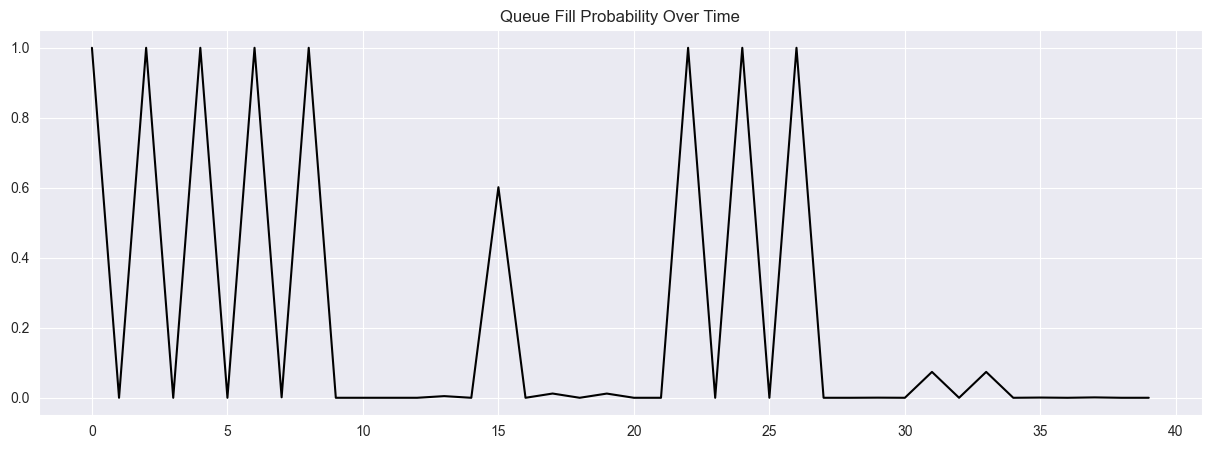

In [38]:
pd.Series(pd_[a:b]).plot(figsize=(15,5), color = 'black', title="Queue Fill Probability Over Time")


In [ ]:
#build training data for the model
data = []

for t in range(500,2000):
    snap = book[t]
    mid = get_mid_price(snap)

    price = snap["bid_prices"][0]
    volume = snap["bid_vol"][0]

    ps = p_surface(price,volume,mid)
    pq = compute_p_queue(book,t)
    pp = p_poisson(lam)
    pd_ = p_dl(snap)

    fill = compute_fill(book,t)
    spread = snap["ask_prices"][0]-snap["bid_prices"][0]
    regime = regime_model.predict([regime_features([snap])[0]])[0]

    data.append([ps,pq,pp,pd_,fill,spread,regime])

df_train = pd.DataFrame(data,columns=[
    "ps","pq","pp","pd","fill","spread","regime"
])

### Optimization Function

In [ ]:
## Optimize funtion

def optimize_weights(df):

    X = df[["ps","pq","pp","pd_"]].values
    fills = df["fill"].values
    spread = df["spread"].values
    
    def objective(w):
        p = X @ w
        profit = p * spread * fills
        return -(profit.mean() - 0.1*np.var(profit))

    w0 = np.array([0.25,0.25,0.25,0.25])
    cons = {"type":"eq","fun":lambda w: np.sum(w)-1}
    bounds = [(0,1)]*4
    res = minimize(objective,w0,bounds=bounds,constraints=cons)

    return res.x

weights = {}

for r in range(N_REGIMES):
    df_r = df_train[df_train.regime==r]
    weights[r] = optimize_weights(df_r)
print(weights)

In [ ]:
snap = book[t]
reg = regime_model.predict([regime_features([snap])[0]])[0]
w = weights[reg]

p_final = (
    w[0]*ps +
    w[1]*pq +
    w[2]*pp +
    w[3]*pd
)